In [12]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Define the directory containing the Parquet files
data_dir = os.path.join('data', 'iam_dataset')

# Read each Parquet file into a separate DataFrame
account_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'account_entitlements.parquet'))
accounts_df = pd.read_parquet(os.path.join(data_dir, 'accounts.parquet'))
applications_df = pd.read_parquet(os.path.join(data_dir, 'applications.parquet'))
entitlement_group_assignments_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_assignments.parquet'))
entitlement_group_relations_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_relations.parquet'))
entitlement_groups_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_groups.parquet'))
entitlements_df = pd.read_parquet(os.path.join(data_dir, 'entitlements.parquet'))
identities_df = pd.read_parquet(os.path.join(data_dir, 'identities.parquet'))
resources_df = pd.read_parquet(os.path.join(data_dir, 'resources.parquet'))

# Print the shapes of the DataFrames
print(f"Shape of account_entitlements_df: {account_entitlements_df.shape}")
print(f"Shape of accounts_df: {accounts_df.shape}")
print(f"Shape of applications_df: {applications_df.shape}")
print(f"Shape of entitlement_group_assignments_df: {entitlement_group_assignments_df.shape}")
print(f"Shape of entitlement_group_relations_df: {entitlement_group_relations_df.shape}")
print(f"Shape of entitlement_groups_df: {entitlement_groups_df.shape}")
print(f"Shape of entitlements_df: {entitlements_df.shape}")
print(f"Shape of identities_df: {identities_df.shape}")
print(f"Shape of resources_df: {resources_df.shape}")

Shape of account_entitlements_df: (968338, 5)
Shape of accounts_df: (336096, 6)
Shape of applications_df: (1000, 4)
Shape of entitlement_group_assignments_df: (170058, 3)
Shape of entitlement_group_relations_df: (581, 2)
Shape of entitlement_groups_df: (711, 5)
Shape of entitlements_df: (22304, 5)
Shape of identities_df: (50000, 8)
Shape of resources_df: (2100, 5)


In [13]:
# Group by 'identity_id' and count the number of accounts for each user
accounts_per_user = accounts_df.groupby('identity_id').size()

# Get the distribution of the number of accounts
account_distribution = accounts_per_user.value_counts()

print("Distribution of accounts per user:")
print(account_distribution)

Distribution of accounts per user:
9     11830
6     11801
5      8889
7      6191
8      5944
4      4994
10      351
Name: count, dtype: int64


Distribution of entitlements per account:
1     265990
2      20105
18      7017
13      5011
17      4014
8       4004
16      3982
12      3978
14      3924
11      3043
15      3019
10      3011
7       2061
20      1989
5       1985
6       1942
19      1020
3          1
Name: count, dtype: int64


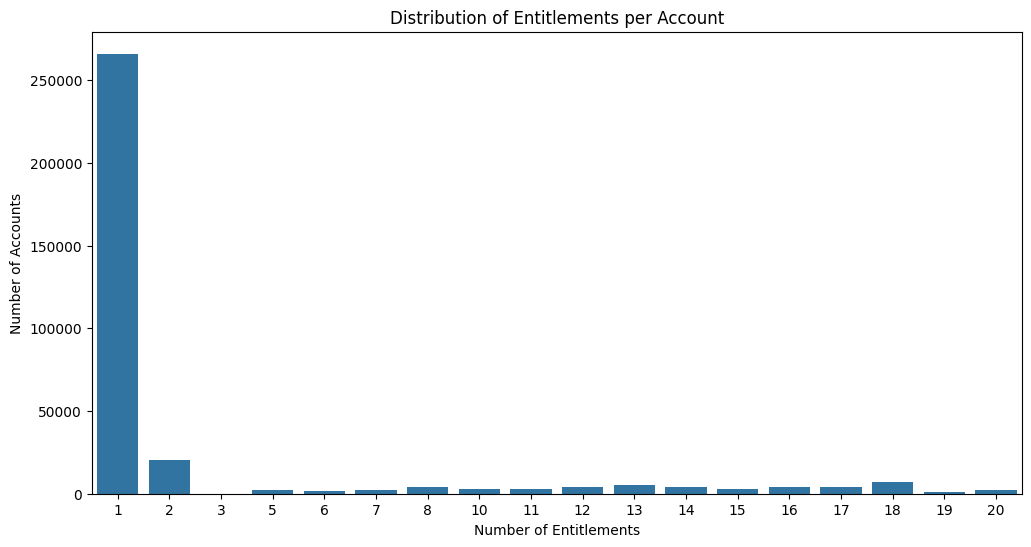

In [14]:


# --- Analysis for account_entitlements ---

# Group by 'account_id' and count the number of entitlements for each account
entitlements_per_account = account_entitlements_df.groupby('account_id').size()

# Get the distribution of the number of entitlements
entitlement_distribution = entitlements_per_account.value_counts()

print("Distribution of entitlements per account:")
print(entitlement_distribution)

# Create a bar plot of the entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_distribution.index, y=entitlement_distribution.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Entitlements per Account")
plt.show()





Distribution of entitlement groups per identity:
3    31984
4    15974
5     2042
Name: count, dtype: int64


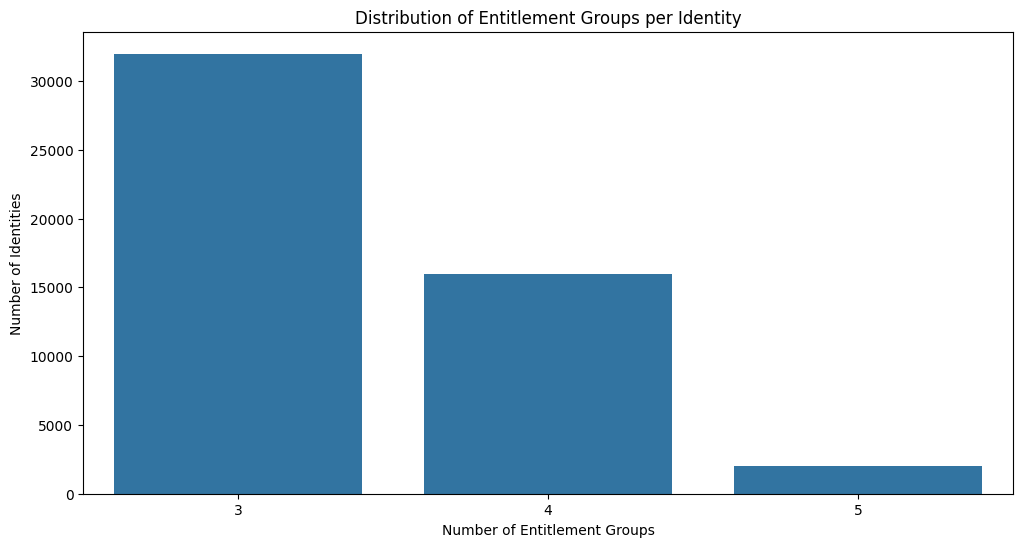

In [15]:
# --- Analysis for entitlement_group_assignments ---

# Group by 'identity_id' and count the number of entitlement groups for each identity
entitlement_groups_per_identity = entitlement_group_assignments_df.groupby('identity_id').size()

# Get the distribution of the number of entitlement groups
entitlement_group_distribution = entitlement_groups_per_identity.value_counts()

print("\nDistribution of entitlement groups per identity:")
print(entitlement_group_distribution)

# Create a bar plot of the entitlement group distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_group_distribution.index, y=entitlement_group_distribution.values)
plt.xlabel("Number of Entitlement Groups")
plt.ylabel("Number of Identities")
plt.title("Distribution of Entitlement Groups per Identity")
plt.show()

In [7]:
print("applications_df columns:", applications_df.columns)
print("resources_df columns:", resources_df.columns)
print("entitlements_df columns:", entitlements_df.columns)
print("account_entitlements_df columns:", account_entitlements_df.columns)
print("accounts_df columns:", accounts_df.columns)

applications_df columns: Index(['app_id', 'app_name', 'business_criticality', 'app_owner_id'], dtype='str')
resources_df columns: Index(['resource_id', 'app_id', 'iga_source_name', 'connection_type'], dtype='str')
entitlements_df columns: Index(['entitlement_id', 'resource_id', 'entitlement_name', 'is_requestable',
       'risk_level'],
      dtype='str')
account_entitlements_df columns: Index(['identity_id', 'account_id', 'entitlement_id', 'grant_date',
       'assignment_type'],
      dtype='str')
accounts_df columns: Index(['identity_id', 'resource_id', 'account_id', 'account_name',
       'is_privileged', 'status'],
      dtype='str')


Distribution of resources per application:
1     640
2     203
3      28
4      48
5      20
6       9
7       2
8       6
9       1
10      8
11      4
12      5
13      6
14      9
15     11
Name: count, dtype: int64


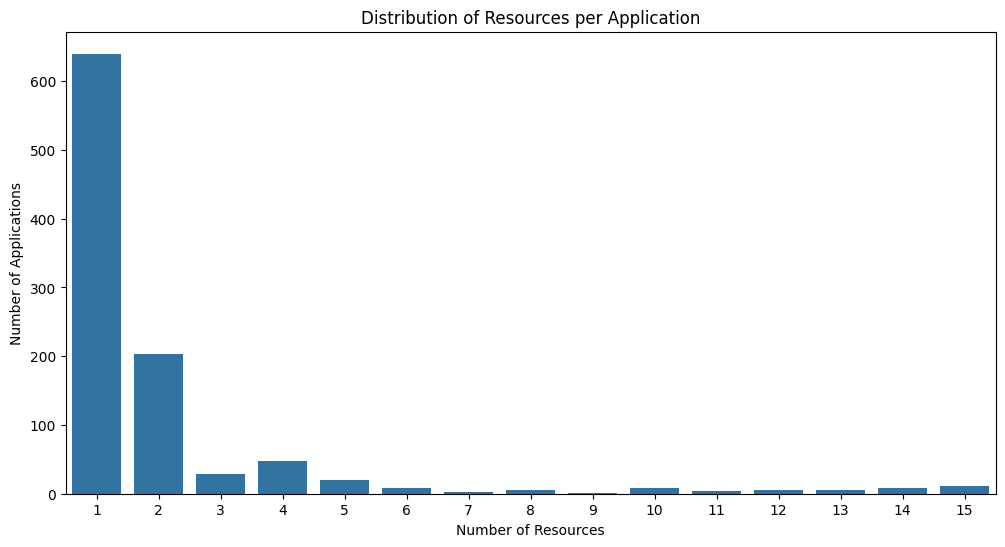

In [16]:
# --- Analysis for application to resource mapping ---

# Group by 'app_id' and count the number of resources for each application
resources_per_app = resources_df.groupby('app_id').size()

# Get the distribution of the number of resources
resource_distribution = resources_per_app.value_counts().sort_index()

print("Distribution of resources per application:")
print(resource_distribution)

# Create a bar plot of the resource distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_distribution.index, y=resource_distribution.values)
plt.xlabel("Number of Resources")
plt.ylabel("Number of Applications")
plt.title("Distribution of Resources per Application")
plt.show()

Distribution of entitlements per resource:
1      465
2      490
3      477
4       68
5       66
      ... 
443      1
449      1
461      1
466      2
485      1
Name: count, Length: 72, dtype: int64


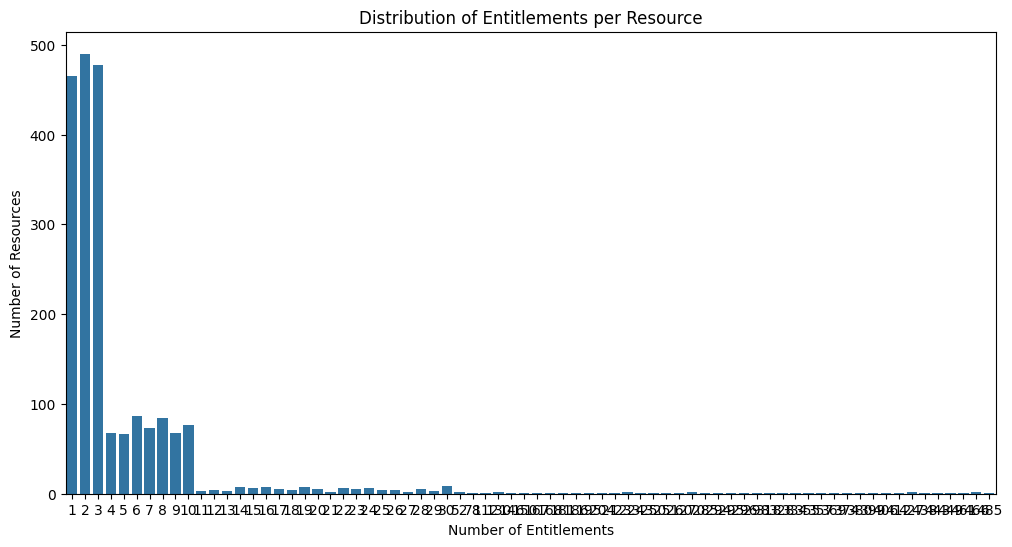

In [17]:
# --- Analysis for resource to entitlement mapping ---

# Group by 'resource_id' and count the number of entitlements for each resource
entitlements_per_resource = entitlements_df.groupby('resource_id').size()

# Get the distribution of the number of entitlements per resource
resource_entitlement_dist = entitlements_per_resource.value_counts().sort_index()

print("Distribution of entitlements per resource:")
print(resource_entitlement_dist)

# Create a bar plot of the resource to entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_entitlement_dist.index, y=resource_entitlement_dist.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Resources")
plt.title("Distribution of Entitlements per Resource")
plt.show()

Distribution of accounts per entitlement:
account_id
1       1067
2        136
3         17
4          4
6          1
        ... 
2056       1
2060       1
2062       1
2910       1
3009       1
Name: count, Length: 103, dtype: int64


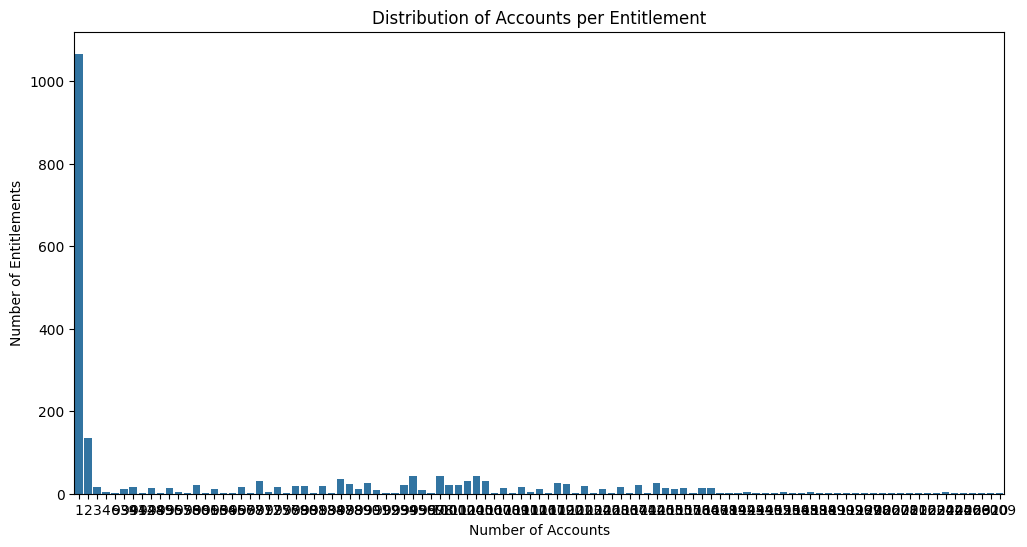

In [20]:
# --- Analysis for entitlement to account mapping ---

# Group by 'entitlement_id' and count the number of unique accounts for each entitlement
accounts_per_entitlement = account_entitlements_df.groupby('entitlement_id')['account_id'].nunique()

# Get the distribution of the number of accounts per entitlement
account_dist_per_entitlement = accounts_per_entitlement.value_counts().sort_index()

print("Distribution of accounts per entitlement:")
print(account_dist_per_entitlement)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=account_dist_per_entitlement.index, y=account_dist_per_entitlement.values)
plt.xlabel("Number of Accounts")
plt.ylabel("Number of Entitlements")
plt.title("Distribution of Accounts per Entitlement")
plt.show()

Distribution of assignment counts per Entitlement Group:
30       1
33       2
34       2
35       2
36       2
        ..
5005     1
5018     1
5053     1
5084     1
50000    1
Name: count, Length: 134, dtype: int64


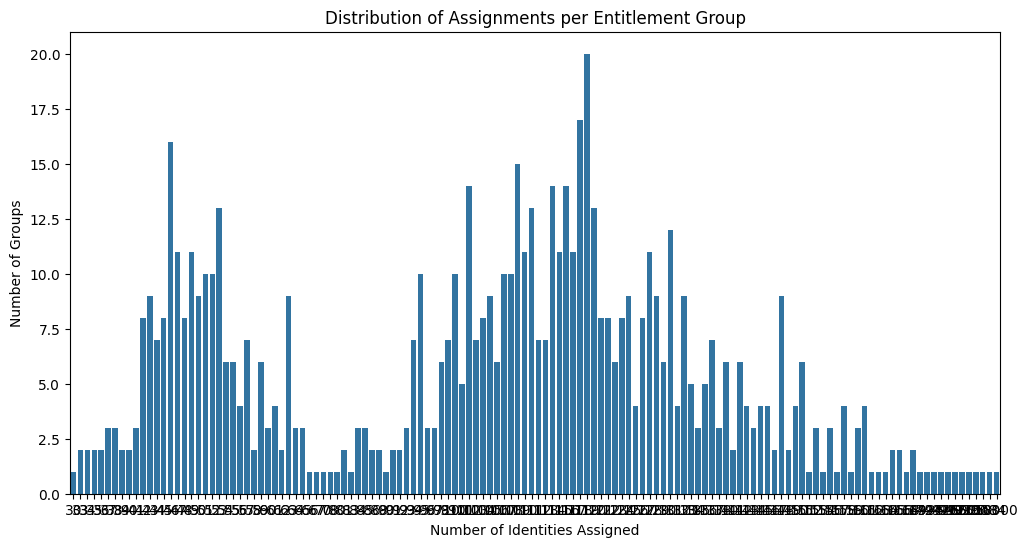

In [19]:
# --- Analysis for entitlement group assignment distribution ---

# Group by 'ent_group_id' and count the number of identities assigned to each group
group_size = entitlement_group_assignments_df.groupby('ent_group_id').size()

# Get the distribution of the number of assignments
group_dist = group_size.value_counts().sort_index()

print("Distribution of assignment counts per Entitlement Group:")
print(group_dist)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=group_dist.index.astype(int), y=group_dist.values)
plt.xlabel("Number of Identities Assigned")
plt.ylabel("Number of Groups")
plt.title("Distribution of Assignments per Entitlement Group")
plt.show()